# Bike Demand Forecasting

## Overview
### Background

With increasing urban population, traffic congestion and saturation and/or lack of public transportation bike sharing proved to be an ingenious environment friendly solution for daily commuters. There has been steady increase in the number of bike share programs worldwide reaching 1608 bike share programs with a fleet of 18.2 million bikes in 2018.

Despite the steady growth in bike sharing programs one of the key challenges faced by aggregators is to estimate the demand for bikes and allocate resources accordingly as the usage rates vary from around three to eight trips per bicycle per day globally2. The variation in usage could be due to multitude of factors one of which we believe are the prevalent weather conditions. We can expect that passengers are more likely to choose bike rides on days when the weather
is pleasant without snowfall and/or heavy winds. Another important factor is time during the day. The demand is more during morning and evening peak traffic hours, and lesser during other times of the day.

Further, a study carried out by Bowman Cutter and Matthew Neidell's on the effect of voluntary information disclosure of information on air quality urging people to reduce ozone emissions found that there is an increase in people choosing alternate methods of transportation on days such warnings are issued, supporting the idea that weather parameters have an effect on individual's behavior and choices.

### Data description

**The response variable is:**  
$Y$ (Cnt): Total bike share by both casual & registered users together  
  
**The predicting variables are:**  
$X_1$ (Instant): Record index  
$X_2$ (Dteday): Day on which the observation is made  
$X_3$ (Season): Season which the observation is made (1 = Winter, 2 = Spring, 3 = Summer, 4 = Fall)  
$X_4$ (Yr): Year on which the observation is made  
$X_5$ (Mnth): Month on which the observation is made  
$X_6$ (Hr): Day on which the observation is made (0 through 23)  
$X_7$ (Holiday): Indictor of a public holiday or not (1 = public holiday, 0 = not a public holiday)  
$X_8$ (Weekday): Day of week (0 through 6)  
$X_9$ (Working day): Indicator of a working day (1 = working day, 0 = not a working day)  
$X_{10}$ (Weathersit): Weather condition (1 = Clear, Few clouds, Partly cloudy, Partly cloudy, 2 = Mist & Cloudy, Mist & Broken clouds, Mist & Few clouds, Mist, 3 = Light Snow, Light Rain, Thunderstorm & Scattered clouds, Light Rain & Scattered clouds, 4 = Heavy Rain, Ice Pallets, Thunderstorm & Mist, Snow & Fog)  
$X_{11}$ (Temp): Normalized temperature in Celsius  
$X_{12}$ (Atemp): Normalized feeling temperature in Celsius  
$X_{13}$ (Hum): Normalized humidity  
$X_{14}$ (Windspeed): Normalized wind speed  
$X_{15}$ (Casual): Bike share by casual users in that hour  
$X_{16}$ (Registered): Bike share by registered users in that hour

***
## Exploratory data analysis
### Read data

In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import statsmodels.stats.outliers_influence as oi
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Data
from pathlib import Path

data_file = Path("bikes.csv")
if not data_file.exists():
    data_file = Path("Bikes.csv")

data = pd.read_csv(data_file)
obs = data.shape[0]
print("There are", obs, "observations in the data")

There are 17379 observations in the data


### Preparing the Data

In [3]:
# Remove the irrelevant columns
clean_data = data.drop(columns = ['instant','dteday','workingday','casual','registered'])

# Convert the numerical categorical variables to predictors
clean_data['season'] = clean_data['season'].astype('category')
clean_data['yr'] = clean_data['yr'].astype('category')
clean_data['mnth'] = clean_data['mnth'].astype('category')
clean_data['hr'] = clean_data['hr'].astype('category')
clean_data['holiday'] = clean_data['holiday'].astype('category')
clean_data['weekday'] = clean_data['weekday'].astype('category')
clean_data['weathersit'] = clean_data['weathersit'].astype('category')

In [4]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_absolute_percentage_error as mape

### Poisson Regression 

In [5]:
sample_size = int(0.8 * len(clean_data))
picked = np.random.choice(clean_data.index, size=sample_size, replace=False)
train = clean_data.loc[picked]
test = clean_data.drop(picked)

model1 = smf.glm(formula='cnt ~ season + yr + mnth + hr + holiday + weekday \
                        + weathersit + temp + atemp + hum + windspeed', data=clean_data, family=sm.families.Poisson()).fit()
print(model1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                17379
Model:                            GLM   Df Residuals:                    17327
Model Family:                 Poisson   Df Model:                           51
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.4146e+05
Date:                Thu, 22 May 2025   Deviance:                   5.7201e+05
Time:                        22:53:05   Pearson chi2:                 5.59e+05
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.9174      0.007    4

We implement poisson regression because of the violation of constant variance in multiple linear regression, even after applying a transformation. All the regression coefficients are statistically significant for this model fit.

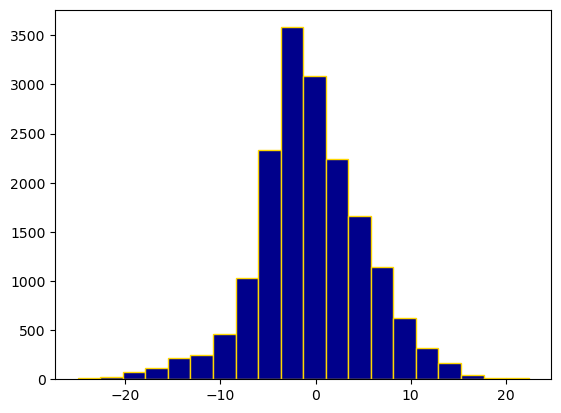

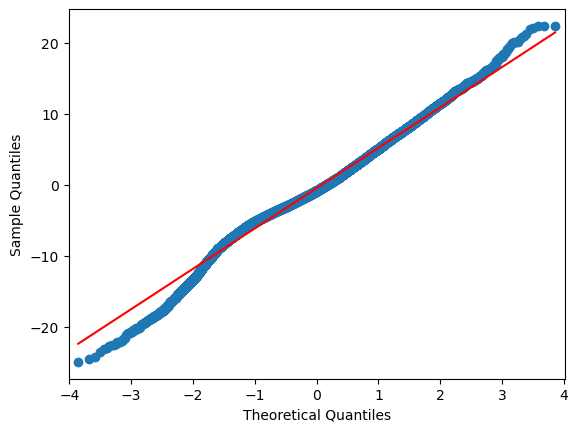

In [6]:
resids1 = model1.resid_deviance
plt.hist(resids1,
         bins=20,
         color='darkblue',
         edgecolor='gold')

sm.qqplot(resids1, line='r', color='darkblue')
plt.show()

We explore the normality assumption using the histogram and the qqnorm plots. From the two plots, the normality assumption looks reasonable, possibly with some heavy tails.

In [7]:
res_deviance = round(model1.deviance,3)
df_residual = model1.df_resid
p_value = 1 - stats.chi2.cdf(res_deviance, df_residual)

result_table = pd.DataFrame({'Res.Deviance': [res_deviance],'df': [df_residual],'p': [p_value]})
print(result_table)

   Res.Deviance     df    p
0    572011.401  17327  0.0


When applying the GOF test, we find that the p-value is approximately equal to 0. 

### Finding Insignificant Variables

In [8]:
print(model1.pvalues[model1.pvalues > 0.05].values)

[]


All 51 predictor variables are significant(inflated p-value problem).

## Accuracy measures for 1 iteration : Poisson Regression

In [9]:
def precision_measure_vecs(y_true, y_pred):
    '''Calculates the precision measure taking two vectors/arrays/pd.Series as input
    
    params:  y_true: test['cnt']
             y_pred: pred_1_test['mean']
    
    returns: value
    '''
    numerator = np.sum((y_pred.values - y_true.values)**2)
    denominator = np.sum( ( y_true.values - np.mean(y_true.values) ) **2)
    return numerator/denominator

In [10]:
def pred_fun(model, test):
    pred = model.predict(test)
    test_pred = pred
    mse_model = mse(test_pred, test['cnt'])
    mae_model = mae(test_pred, test['cnt'])
    mape_model = mape(test_pred, test['cnt'])
    pm_model = precision_measure_vecs(test_pred, test['cnt'])
    pred_meas = [round(mse_model,4), round(mae_model,4), round(mape_model,4), float(np.round(pm_model, 4))]
    return pred_meas

Here, we define the prediction function with output of MSE, MAE, MAPE and PM.

In [11]:
np.random.seed(0)
sample_size = int(0.8 * len(clean_data))
picked = np.random.choice(np.arange(len(clean_data)), size=sample_size, replace=False)
train = clean_data.iloc[picked]
test = clean_data.iloc[~np.isin(np.arange(len(clean_data)), picked)]

model1_train = smf.glm(formula='cnt ~ season + yr + mnth + hr + holiday + weekday \
                        + weathersit + temp + atemp + hum + windspeed', data=train, family=sm.families.Poisson()).fit()

pred_fun(model1_train, test)

[7602.21, 58.4627, 0.4072, 0.3028]

Here, we are preparing the data for prediction, particularly splitting the data into training and testing data, with a distribution of 80% of data going to training and 20% to testing using random sampling. We then apply the set of functions to obtain the prediction accuracy for applying the random data split once.

## Accuracy measures for 100 iterations : Poisson Regression

In [12]:
np.random.seed(0)
pred1_meas = np.zeros((4, 100))
for i in range(100):
    sample_size = int(0.8 * len(clean_data))
    picked = np.random.choice(np.arange(len(clean_data)), size=sample_size, replace=False)
    train = clean_data.iloc[picked]
    test = clean_data.iloc[~np.isin(np.arange(len(clean_data)), picked)]
    model1_train = smf.glm(formula='cnt ~ season + yr + mnth + hr + holiday + weekday \
                        + weathersit + temp + atemp + hum + windspeed', data=train, family=sm.families.Poisson()).fit()
    pred1_meas[:, i] = pred_fun(model1_train, test)
model1_ave = np.round(np.mean(pred1_meas, axis=1), 4)
model1_ave = [float(format(num, '.10f')) for num in model1_ave]
model1_ave

[8155.8819, 60.4084, 0.4131, 0.3205]

The function above splits the dataset into 80% as training and 20% as testing and iterates 100 times. Within each iteration, it calculates the output metrics in the prediction function and returns the metric values.

The average accuracy measures of MSE, MAE, MAPE and PM after 100 iterations are shown above. Precision measure (PM) is more appropriate in evaluating prediction accuracy.

the Poisson regression model performs similar compared to the multiple linear regression with the log-transformed response.

In [13]:
model1.pvalues

Intercept           0.000000e+00
season[T.2]         0.000000e+00
season[T.3]         0.000000e+00
season[T.4]         0.000000e+00
yr[T.1]             0.000000e+00
mnth[T.2]          1.491483e-198
mnth[T.3]           0.000000e+00
mnth[T.4]          9.513435e-263
mnth[T.5]           0.000000e+00
mnth[T.6]          9.213739e-271
mnth[T.7]           1.147273e-59
mnth[T.8]          6.520720e-240
mnth[T.9]           0.000000e+00
mnth[T.10]         2.950218e-265
mnth[T.11]          1.054951e-30
mnth[T.12]          3.196598e-22
hr[T.1]             0.000000e+00
hr[T.2]             0.000000e+00
hr[T.3]             0.000000e+00
hr[T.4]             0.000000e+00
hr[T.5]             0.000000e+00
hr[T.6]             0.000000e+00
hr[T.7]             0.000000e+00
hr[T.8]             0.000000e+00
hr[T.9]             0.000000e+00
hr[T.10]            0.000000e+00
hr[T.11]            0.000000e+00
hr[T.12]            0.000000e+00
hr[T.13]            0.000000e+00
hr[T.14]            0.000000e+00
hr[T.15]  

Let's extract the p-value of each coefficient after fitting Poisson regression model. As you can see, all coefficients are statistically significant as p-values are close or equal to zero. It's hard to justify which predicting variables have more explanatory power over the others. Thus, we need to perform variable selection.

In [14]:
# Approach: Subsample 30% of the initial data sample & repeat 100 times
count = 1
n = len(clean_data)
B = 100
ncoef = len(model1.params)
pv_matrix = np.zeros((ncoef, B))

while count <= B:
    subsample = np.random.choice(n, size=int(n*0.3), replace=False)
    subdata = clean_data.iloc[subsample, :]
    submod = smf.glm(formula='cnt ~ season + yr + mnth + hr + holiday + weekday \
                        + weathersit + temp + atemp + hum + windspeed', data=subdata, family=sm.families.Poisson()).fit()
    pv_matrix[:, count-1] = submod.pvalues
    count += 1

alpha = 0.01
pv_significant = np.sum(pv_matrix < alpha, axis=1)

Before performing variable selection, let’s explore statistical significance of the regression coefficients for the Poisson regression model. Because of the large sample size, we need to perform a similar analysis using sub-sampling for identifying statistical significance. Specifically, we consider a 30% sub-sample of the data, with 100 repetitions of the sub-sampling. We apply now the Poisson regression model to each sub-sample, then get the p-values of the regression coefficients for each sub-sample. Please note that percentage of data to sub-sample is a tunning parameter.

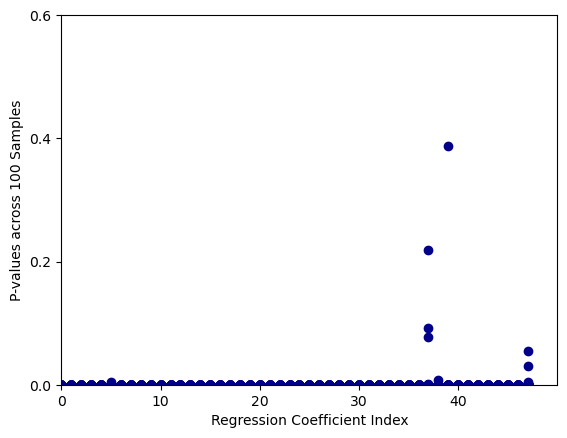

In [15]:
idx_scoef = np.where(pv_significant >= 95)[0]
plt.plot(pv_matrix[idx_scoef, :], marker='o', linestyle='None', color='darkblue')
plt.xlabel("Regression Coefficient Index")
plt.ylabel("P-values across 100 Samples")
plt.yticks(np.arange(0, 0.8, 0.2))
plt.xticks(np.arange(0, 50, 10))
plt.xlim(0,50)
plt.ylim(0,0.6)
plt.show()

From the plot above, we can see four coefficients are larger than 0.01 which are considered statistically insignificant. 

In [16]:
idx_scoef = np.where(pv_significant >= 95)[0]
len(idx_scoef)

48

For each regression coefficient we count how many of the p-values are smaller than the significance level 0.01. Here, we only focus on those that have 95% of their p-values larger than the significance level.

Which regression coefficients are statistically significant? i.e. Those variables which have p-values less than alpha on more than 95 iterations out of 100 are concluded to be statistically significant - 48 out of 52

In [17]:
model1.params

Intercept          2.917366
season[T.2]        0.274074
season[T.3]        0.267229
season[T.4]        0.457991
yr[T.1]            0.468568
mnth[T.2]          0.113477
mnth[T.3]          0.223629
mnth[T.4]          0.181256
mnth[T.5]          0.244622
mnth[T.6]          0.196331
mnth[T.7]          0.098776
mnth[T.8]          0.195068
mnth[T.9]          0.270833
mnth[T.10]         0.187673
mnth[T.11]         0.061080
mnth[T.12]         0.045320
hr[T.1]           -0.466686
hr[T.2]           -0.839682
hr[T.3]           -1.507858
hr[T.4]           -2.110449
hr[T.5]           -0.956563
hr[T.6]            0.400500
hr[T.7]            1.422873
hr[T.8]            1.916567
hr[T.9]            1.391884
hr[T.10]           1.123196
hr[T.11]           1.269600
hr[T.12]           1.447488
hr[T.13]           1.427095
hr[T.14]           1.364778
hr[T.15]           1.405028
hr[T.16]           1.628131
hr[T.17]           2.036237
hr[T.18]           1.970314
hr[T.19]           1.674867
hr[T.20]           1

In [18]:
ll_null = model1.null_deviance / -2 
ll_model = model1.llf  
pseudo_r2 = 1 - (ll_model / ll_null)
float(np.round(pseudo_r2,4))

0.7638

In order to determine threshold of VIF, we need to calculate R^2 of model1 first.

In [19]:
from statsmodels.stats.moment_helpers import cov2corr
from copy import deepcopy
from numpy.linalg import det
from collections import defaultdict
def r_car_vif(model_obj, round_to=None):
    """Variance Inflation Factor calculation modeled on R car::vif approach."""
    
    if not isinstance(model_obj, sm.regression.linear_model.RegressionResultsWrapper):
        raise ValueError("The model is not a statsmodelsregression.linear_model.RegressionResultsWrapper object")
    
    # V and R are the variable names used in car::vif
    # V has a reference to the model_obj.cov_params() after dropping the 'intercept'
    # thus throws index/shape error on repeated calls without copying the original model
    model = deepcopy(model_obj) 
    
    # calculate the variance/covariance matrix
    V = model.cov_params()
        
    # drop the intercept from the V matrix
    if 'Intercept' in V.columns:
        V.drop(index='Intercept', axis=0, inplace=True)
        V.drop(columns='Intercept', axis=1 , inplace=True)
    
    # calc the correlation matrix, then the determinant of R
    R = cov2corr(V)
    detR = det(R)
    
    # extract and process the predictor names
    raw_names = model.model.exog_names
    if 'Intercept' in raw_names:
        raw_names.remove('Intercept')
    stripped_names = [x[ : x.find('[')] if '[' in x else x for x in raw_names]
    
    # extract predictor indicies
    pred_indicies = defaultdict(list)
    for i,t in enumerate(stripped_names):
        pred_indicies[t].append(i)
    
    # for predictor names in final df
    pred_names = list(pred_indicies.keys())
    
    results = []
    for k,v in pred_indicies.items():
        df = len(v)
        first, last = stripped_names.index(k), len(stripped_names)-stripped_names[::-1].index(k)
        
        # the car::vif symbol is subs; using _slice here to more closely align with Numpy
        _slice = slice(first,last)
        # select the "in-focus" predictors; calculate determinant
        detA = det(R[_slice, _slice])
        
        # drop the "out-of-focus" predictors; calculate determinant
        B = np.delete(R, _slice, axis=0)
        B = np.delete(B, _slice, axis=1)
        detB = det(B)
        
        # compute vif, gvif_pwr
        gvif = detA * detB / detR
        gvif_pwr = gvif**(1/(2*df))
        results.append([gvif, df, gvif_pwr])
        
    # construct dataframe
    df = pd.DataFrame(results, columns=['GVIF', 'Df', 'GVIF^(1/(2*Df)'])
    df.insert(loc = 0, column = 'Names', value = pred_names)
    
    if round_to:
        df = df.round(round_to)
    
    return df

In [20]:
print(r_car_vif(model1, round_to=3))
thre = max(10,(1-pseudo_r2))
thre


         Names     GVIF  Df  GVIF^(1/(2*Df)
0       season  143.326   3           2.288
1           yr    1.025   1           1.013
2         mnth  298.271  11           1.296
3           hr    1.743  23           1.012
4      holiday    1.104   1           1.051
5      weekday    1.118   6           1.009
6   weathersit    1.384   2           1.085
7         temp   42.778   1           6.540
8        atemp   36.164   1           6.014
9          hum    1.958   1           1.399
10   windspeed    1.142   1           1.069


10

The VIF values for temp, atemp, mnth, and season being greater than the threshold of 10 suggest a multicollinearity issue in the model. This means that these predictors are highly correlated with each other, which can inflate standard errors and lead to unreliable coefficient estimates.

  Coefficient  Estimate  P-value  Freq
0  mnth[T.11]     0.061      0.0    79
1  mnth[T.12]     0.045      0.0    79
2        temp     0.164      0.0    79


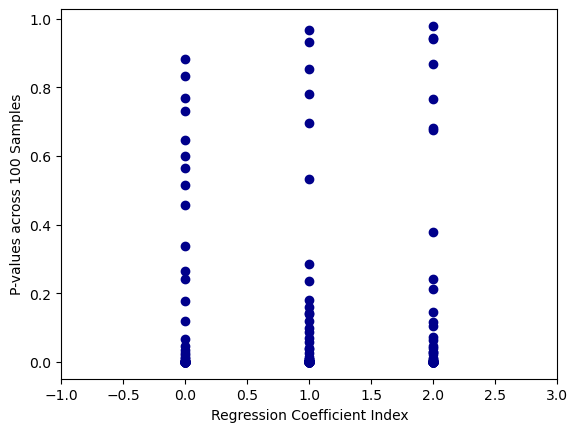

In [21]:
idx_icoef = np.where(pv_significant < 85)[0]

coefficients = model1.params.iloc[idx_icoef]
p_values = model1.pvalues.iloc[idx_icoef]
result_df = pd.DataFrame({
    'Coefficient': coefficients.index,
    'Estimate': coefficients.values,
    'P-value': p_values.values,
    'Freq': pv_significant[idx_icoef]
})
print(result_df.round(3))

plt.plot(pv_matrix[idx_icoef, :], marker='o', linestyle='None', color='darkblue')
plt.xlabel("Regression Coefficient Index")
plt.ylabel("P-values across 100 Samples")
plt.xticks(np.arange(-1,4,0.5))
plt.xlim(-1,3)
plt.show()

Here, we explore the the lack of statistical significance. Only three of the regression coefficients corresponding to the dummy variables for November, December and temp are not statistically significant, with about 75% of the p-values being smaller than the significance level. 
The plot of the p-values shows that the distribution of the p-values is approximately uniform.

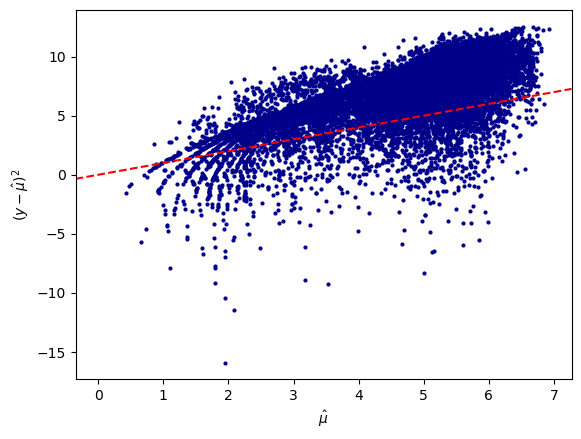

In [22]:
# Overdispersion (a probable cause of inflated significance)
plt.scatter(np.log(model1.fittedvalues), np.log((train['cnt'] - model1.fittedvalues)**2), marker='o', color='darkblue', s=4)
plt.xlabel(r'$\hat{\mu}$')
plt.ylabel(r'$(y - \hat{\mu})^2$')
plt.axline((0, 0), slope=1, color='red', linestyle='--')
plt.show()

The chunk of code above is exploring overdispersion. We are plotting the log of fitted values against the log of the squared differences between observed and fitted, some sort of measure of variability. From the plot, it is evident that for most of observations, variance is usually higher than the mean and hence potentially overdispersion in the data.

In [23]:
#overdispersion parameter
dp = np.sum(model1.resid_pearson**2) / model1.df_resid
float(np.round(dp,4))

32.2539

The dispersion parameter comes out to be around 32, much larger than our initial threshold, again indicating overdispersion.

In [24]:
# see how the coefficients are affected owing to overdispersion
dp_float = float(dp)
original_estimates = model1.pvalues

# dispersion_model = smf.glm(formula='cnt ~ season + yr + mnth + hr + holiday + weekday \
#                         + weathersit + temp + atemp + hum + windspeed', data=clean_data, family=sm.families.Poisson(), dispersion_model=dp_float).fit()
# dispersion_estimates = dispersion_model.pvalues
# result_df = pd.DataFrame({'original_estimates': original_estimates, 'dispersion_estimates': dispersion_estimates})

# Get robust standard errors and p-values
robust_model = smf.glm(formula='cnt ~ season + yr + mnth + hr + holiday + weekday \
                               + weathersit + temp + atemp + hum + windspeed',
                       data=clean_data,
                       family=sm.families.Poisson()).fit(cov_type='HC0')
robust_pvalues = robust_model.pvalues
result_df = pd.DataFrame({'original_estimates': original_estimates, 'dispersion_estimates': robust_pvalues})
print(result_df)

                 original_estimates  dispersion_estimates
Intercept              0.000000e+00          0.000000e+00
season[T.2]            0.000000e+00          1.389314e-32
season[T.3]            0.000000e+00          1.844921e-22
season[T.4]            0.000000e+00          1.435846e-65
yr[T.1]                0.000000e+00          0.000000e+00
mnth[T.2]             1.491483e-198          1.834831e-07
mnth[T.3]              0.000000e+00          1.280233e-19
mnth[T.4]             9.513435e-263          2.144003e-08
mnth[T.5]              0.000000e+00          4.914168e-13
mnth[T.6]             9.213739e-271          2.754174e-08
mnth[T.7]              1.147273e-59          1.350621e-02
mnth[T.8]             6.520720e-240          3.781747e-07
mnth[T.9]              0.000000e+00          9.687096e-15
mnth[T.10]            2.950218e-265          4.696318e-08
mnth[T.11]             1.054951e-30          7.071005e-02
mnth[T.12]             3.196598e-22          1.257987e-01
hr[T.1]       

Comparing the p-values before and after adjusting for dispersion reveals the impact of overdispersion on statistical significance. Initially, very small p-values suggest many predictors are highly significant. After adjustment, the p-values increase for several variables, reflecting inflated standard errors and previously underestimated variability. Some, like temp, become insignificant, indicating their effect was overstated. This underscores the need to check for overdispersion in Poisson models, as ignoring it can lead to misleading conclusions. A quasi-Poisson or negative binomial model may be more appropriate for reliable inference.

In [25]:
# effect of overdispersion on model coefficients 
print(len(np.where(robust_model.params < 0.025)[0]))
print(len(np.where(model1.params < 0.025)[0]))

10
10


The code counts the number of coefficients whose absolute z-scores are less than 0.025, effectively measuring how many coefficients have extremely small test statistics between original Poisson Regression model and dispersion-adjusted model.

Both model return the same number of coefficients, indicating that adjusting for dispersion did not significantly change the z-scores of the coefficients 